In [ ]:
# Cell 1 - Import dependencies
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Google Colab was not detected. Drive mounting was skipped.')


Mounted at /content/drive


In [ ]:
# Cell 2 - Define dataset settings
DATA_PATH = Path('/content/drive/MyDrive/P4AIDS/titanic.csv')
TARGET_COL = 'Survived'
RANDOM_STATE = 42
CV_FOLDS = 5

print(f'Dataset path: {DATA_PATH}')
print(f'Target column: {TARGET_COL}')
print(f'Random state: {RANDOM_STATE}')
print(f'Cross-validation folds: {CV_FOLDS}')

Dataset path: /content/drive/MyDrive/P4AIDS/titanic.csv
Target column: Survived
Random state: 42
Cross-validation folds: 5


In [ ]:
# Cell 3 - Load dataset and inspect overview
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}.'
    )

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
display(df.head())
print('\nDataset info:')
df.info()

print('\nTarget distribution:')
display(
    pd.DataFrame({
        'count': df[TARGET_COL].value_counts().sort_index(),
        'proportion': df[TARGET_COL].value_counts(normalize=True).sort_index().round(4)
    })
)

print('\nMissing value ratios:')
display(df.isna().mean().sort_values(ascending=False).rename('missing_ratio').to_frame())


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Target distribution:


,count,proportion
Survived,,
0,549,0.6162
1,342,0.3838



Missing value ratios:


,missing_ratio
Cabin,0.771044
Age,0.198653
Embarked,0.002245
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


## Preprocessing Justification

- `Name` and `Ticket` are dropped because they are high-cardinality, ID-like fields.
- `Cabin` has critical missingness, but instead of discarding it entirely we extract a lower-cardinality `Deck` feature and map missing cabins to `Unknown`.
- `Age` has moderate missingness, so it is imputed with the median age inside each `Pclass`.
- `Embarked` has very few missingness, so it is filled with the mode.
- `Fare` is heavily right-skewed, so `log1p` is applied before scaling.
- `Pclass` is treated as categorical, while `Sex` is binary encoded.
- `FamilySize` and `IsAlone` are added to capture family-travel effects that are not explicit in `SibSp` and `Parch` alone.
- Numerical features are scaled with `StandardScaler` for most models, while `MultinomialNB` uses a separate `MinMaxScaler`-based preprocessor.


In [ ]:
# Cell 4 - Engineer features and split the data
BASE_FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Cabin']
MODEL_FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'FamilySize', 'IsAlone']
NUMERIC_FEATURES = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
CATEGORICAL_FEATURES = ['Pclass', 'Embarked', 'Deck']
BINARY_FEATURES = ['Sex', 'IsAlone']

missing_columns = [column for column in BASE_FEATURES + [TARGET_COL] if column not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

def add_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    data = dataframe.copy()
    data = data[BASE_FEATURES].copy()

    cabin_filled = data['Cabin'].fillna('Unknown').astype(str).str.strip()
    data['Deck'] = np.where(cabin_filled.eq('Unknown'), 'Unknown', cabin_filled.str[0])
    data['FamilySize'] = data['SibSp'].fillna(0) + data['Parch'].fillna(0) + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

    return data[MODEL_FEATURES]

X = df[BASE_FEATURES].copy()
y = df[TARGET_COL].astype(int).copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print('Split sizes:')
print(f'Train: {X_train.shape[0]} rows ({X_train.shape[0] / len(df):.2%})')
print(f'Validation: {X_val.shape[0]} rows ({X_val.shape[0] / len(df):.2%})')
print(f'Test: {X_test.shape[0]} rows ({X_test.shape[0] / len(df):.2%})')

display(add_engineered_features(X_train).head())


Split sizes:
Train: 623 rows (69.92%)
Validation: 134 rows (15.04%)
Test: 134 rows (15.04%)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,FamilySize,IsAlone
748,1,male,19.0,1,0,53.1000,S,D,2,0
45,3,male,NaN,0,0,8.0500,S,Unknown,1,1
28,3,female,NaN,0,0,7.8792,Q,Unknown,1,1
633,1,male,NaN,0,0,0.0000,S,Unknown,1,1
403,3,male,28.0,1,0,15.8500,S,Unknown,2,0



Engineered feature summaries against the target:

Deck vs Survived


,PassengerCount,SurvivalRate
Deck,,
Unknown,687,0.2999
C,59,0.5932
B,47,0.7447
D,33,0.7576
E,32,0.7500
A,15,0.4667
F,13,0.6154
G,4,0.5000
T,1,0.0000



FamilySize vs Survived


,PassengerCount,SurvivalRate
FamilySize,,
1,537,0.3035
2,161,0.5528
3,102,0.5784
4,29,0.7241
5,15,0.2000
6,22,0.1364
7,12,0.3333
8,6,0.0000
11,7,0.0000



IsAlone vs Survived


,PassengerCount,SurvivalRate
IsAlone,,
Not Alone,354,0.5056
Alone,537,0.3035


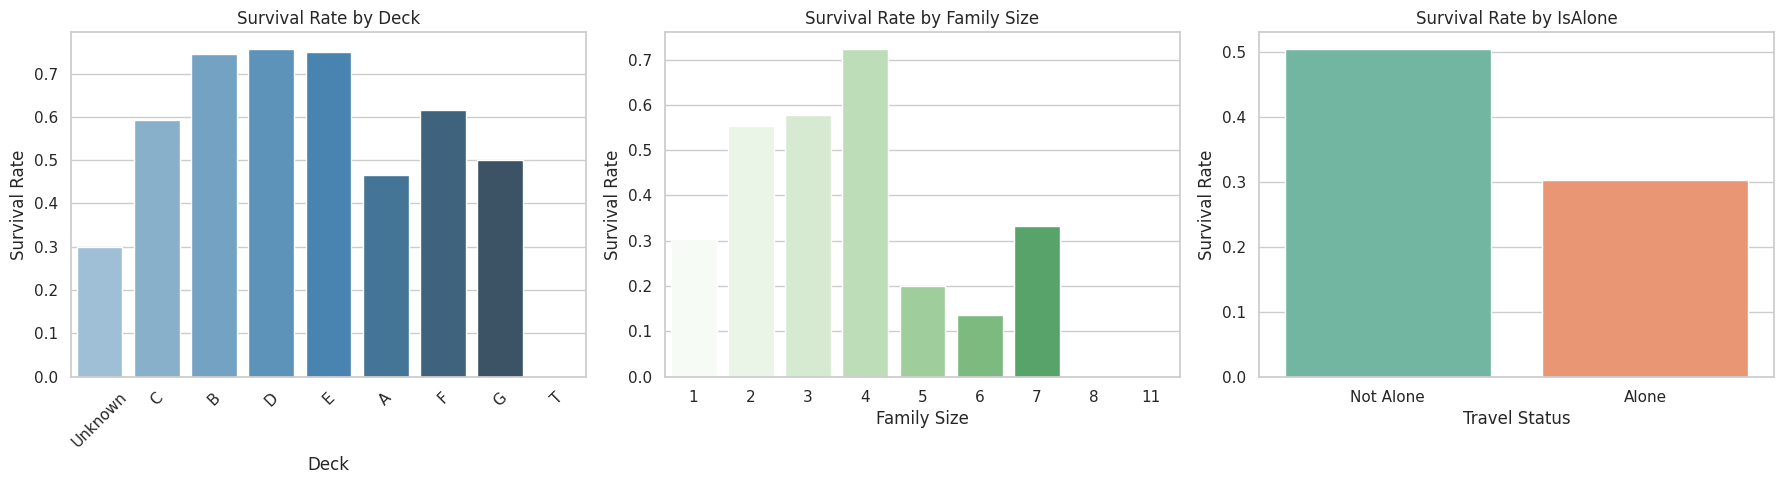

In [ ]:
# Cell 4A - Temporary analysis of engineered features against the target
engineered_analysis_df = add_engineered_features(df)
engineered_analysis_df[TARGET_COL] = df[TARGET_COL].astype(int)

deck_summary = (
    engineered_analysis_df
    .groupby('Deck')[TARGET_COL]
    .agg(PassengerCount='count', SurvivalRate='mean')
    .sort_values(by=['PassengerCount', 'SurvivalRate'], ascending=[False, False])
)

family_summary = (
    engineered_analysis_df
    .groupby('FamilySize')[TARGET_COL]
    .agg(PassengerCount='count', SurvivalRate='mean')
    .sort_index()
)

is_alone_summary = (
    engineered_analysis_df
    .groupby('IsAlone')[TARGET_COL]
    .agg(PassengerCount='count', SurvivalRate='mean')
    .rename(index={0: 'Not Alone', 1: 'Alone'})
)

print('\nEngineered feature summaries against the target:')
print('\nDeck vs Survived')
display(deck_summary.round({'SurvivalRate': 4}))

print('\nFamilySize vs Survived')
display(family_summary.round({'SurvivalRate': 4}))

print('\nIsAlone vs Survived')
display(is_alone_summary.round({'SurvivalRate': 4}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=deck_summary.reset_index(),
    x='Deck',
    y='SurvivalRate',
    hue='Deck',
    palette='Blues_d',
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Survival Rate by Deck')
axes[0].set_xlabel('Deck')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=family_summary.reset_index(),
    x='FamilySize',
    y='SurvivalRate',
    hue='FamilySize',
    palette='Greens',
    legend=False,
    ax=axes[1],
)
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_xlabel('Family Size')
axes[1].set_ylabel('Survival Rate')

sns.barplot(
    data=is_alone_summary.reset_index(),
    x='IsAlone',
    y='SurvivalRate',
    hue='IsAlone',
    palette='Set2',
    legend=False,
    ax=axes[2],
)
axes[2].set_title('Survival Rate by IsAlone')
axes[2].set_xlabel('Travel Status')
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()


Distribution of engineered features split by Survived:

Deck distribution within each survival class


SurvivalLabel,Did Not Survive,Survived
Deck,,
A,0.0146,0.0205
B,0.0219,0.1023
C,0.0437,0.1023
D,0.0146,0.0731
E,0.0146,0.0702
F,0.0091,0.0234
G,0.0036,0.0058
T,0.0018,0.0000
Unknown,0.8761,0.6023



FamilySize distribution within each survival class


SurvivalLabel,Did Not Survive,Survived
FamilySize,,
1,0.6812,0.4766
2,0.1311,0.2602
3,0.0783,0.1725
4,0.0146,0.0614
5,0.0219,0.0088
6,0.0346,0.0088
7,0.0146,0.0117
8,0.0109,0.0000
11,0.0128,0.0000



IsAlone distribution within each survival class


SurvivalLabel,Did Not Survive,Survived
IsAlone,,
Alone,0.6812,0.4766
Not Alone,0.3188,0.5234


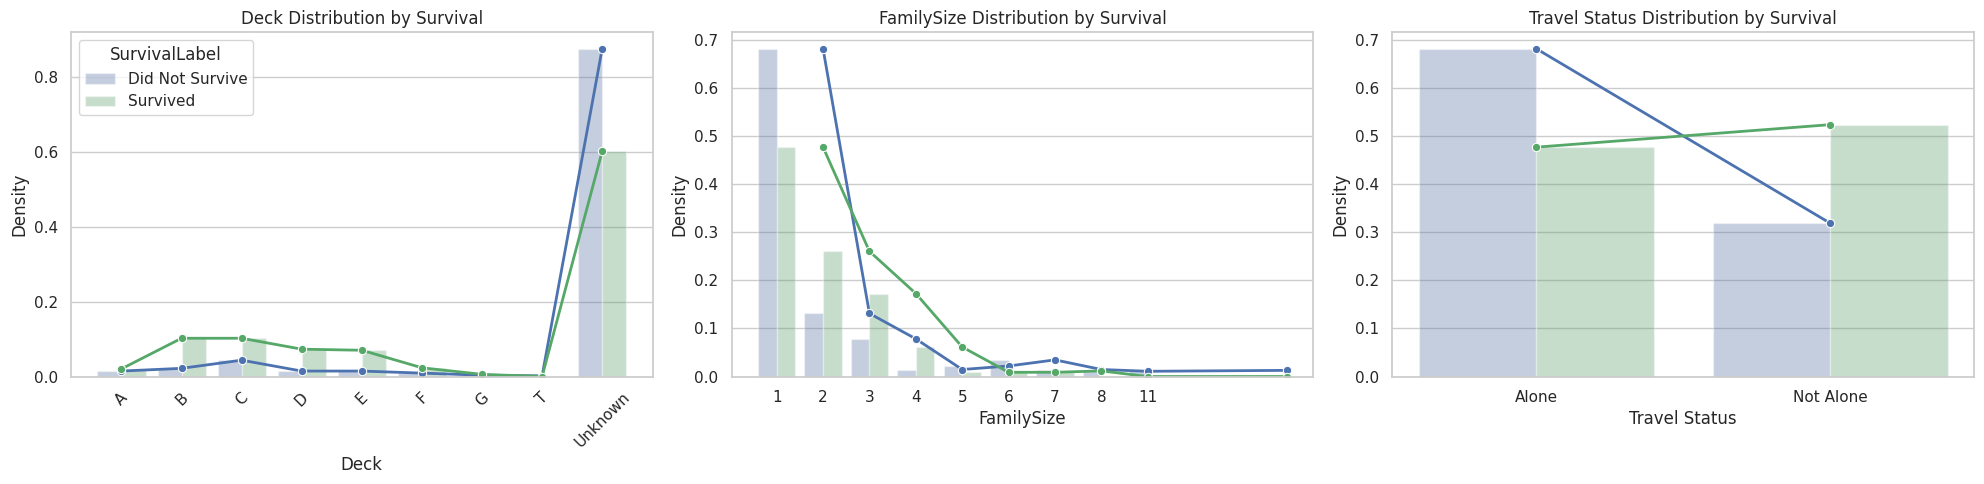

In [ ]:
# Cell 4B - Temporary distribution analysis of engineered features split by the target
survival_label_map = {0: 'Did Not Survive', 1: 'Survived'}
engineered_distribution_df = add_engineered_features(df)
engineered_distribution_df[TARGET_COL] = df[TARGET_COL].astype(int)
engineered_distribution_df['SurvivalLabel'] = engineered_distribution_df[TARGET_COL].map(survival_label_map)

deck_distribution = pd.crosstab(
    engineered_distribution_df['Deck'],
    engineered_distribution_df['SurvivalLabel'],
    normalize='columns',
).round(4)

family_distribution = pd.crosstab(
    engineered_distribution_df['FamilySize'],
    engineered_distribution_df['SurvivalLabel'],
    normalize='columns',
).round(4)

is_alone_distribution = pd.crosstab(
    engineered_distribution_df['IsAlone'].map({0: 'Not Alone', 1: 'Alone'}),
    engineered_distribution_df['SurvivalLabel'],
    normalize='columns',
).round(4)

print('\nDistribution of engineered features split by Survived:')
print('\nDeck distribution within each survival class')
display(deck_distribution)

print('\nFamilySize distribution within each survival class')
display(family_distribution)

print('\nIsAlone distribution within each survival class')
display(is_alone_distribution)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

distribution_palette = {
    'Did Not Survive': '#4C72B0',
    'Survived': '#55A868',
}

def plot_density_bars_with_lines(distribution_df, feature_name, axis, rotate_ticks=False):
    plot_df = (
        distribution_df
        .reset_index()
        .melt(id_vars=distribution_df.index.name, var_name='SurvivalLabel', value_name='Density')
    )

    sns.barplot(
        data=plot_df,
        x=distribution_df.index.name,
        y='Density',
        hue='SurvivalLabel',
        palette=distribution_palette,
        alpha=0.35,
        ax=axis,
    )
    sns.lineplot(
        data=plot_df,
        x=distribution_df.index.name,
        y='Density',
        hue='SurvivalLabel',
        palette=distribution_palette,
        marker='o',
        linewidth=2,
        legend=False,
        ax=axis,
    )

    axis.set_title(f'{feature_name} Distribution by Survival')
    axis.set_xlabel(feature_name)
    axis.set_ylabel('Density')
    if rotate_ticks:
        axis.tick_params(axis='x', rotation=45)

plot_density_bars_with_lines(deck_distribution, 'Deck', axes[0], rotate_ticks=True)
plot_density_bars_with_lines(family_distribution, 'FamilySize', axes[1])
plot_density_bars_with_lines(is_alone_distribution, 'Travel Status', axes[2])

handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    legend = axis.get_legend()
    if legend is not None:
        legend.remove()
axes[0].legend(handles[:2], labels[:2], title='SurvivalLabel')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5 - Build preprocessing, cross-validation, and evaluation utilities
class TitanicCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        data = X.copy()
        self.age_by_pclass_ = data.groupby('Pclass')['Age'].median().to_dict()
        self.global_age_median_ = data['Age'].median()
        embarked_mode = data['Embarked'].mode(dropna=True)
        self.embarked_mode_ = embarked_mode.iloc[0] if not embarked_mode.empty else 'S'
        return self

    def transform(self, X):
        data = X.copy()

        data['Age'] = data['Age'].fillna(data['Pclass'].map(self.age_by_pclass_))
        data['Age'] = data['Age'].fillna(self.global_age_median_)
        data['Embarked'] = data['Embarked'].fillna(self.embarked_mode_)
        data['Deck'] = data['Deck'].fillna('Unknown')
        data['Fare'] = np.log1p(data['Fare'].clip(lower=0))
        data['Sex'] = data['Sex'].map({'male': 0, 'female': 1}).astype(int)
        data['Pclass'] = data['Pclass'].astype(str)
        data['Embarked'] = data['Embarked'].astype(str)
        data['Deck'] = data['Deck'].astype(str)

        return data

def build_preprocessor(model_name: str) -> ColumnTransformer:
    scaler = MinMaxScaler() if model_name == 'Naive Bayes' else StandardScaler()

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler),
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, NUMERIC_FEATURES),
            ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
            ('binary', 'passthrough', BINARY_FEATURES),
        ],
        remainder='drop',
    )

def build_model_pipeline(model_name: str, estimator):
    return Pipeline([
        ('feature_engineering', FunctionTransformer(add_engineered_features, validate=False)),
        ('cleaning', TitanicCleaner()),
        ('preprocessor', build_preprocessor(model_name)),
        ('classifier', estimator),
    ])

def get_model_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict(X)

def build_confusion_frame(y_true, y_pred) -> pd.DataFrame:
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return pd.DataFrame(
        matrix,
        index=['Actual 0', 'Actual 1'],
        columns=['Predicted 0', 'Predicted 1'],
    )

CV_STRATEGY = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
CV_SCORING = {
    'Accuracy': 'accuracy',
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0),
    'F1': make_scorer(f1_score, zero_division=0),
    'F1_Class_0': make_scorer(f1_score, pos_label=0, zero_division=0),
    'F1_Class_1': make_scorer(f1_score, pos_label=1, zero_division=0),
    'ROC_AUC': 'roc_auc',
}

def run_cross_validation(name, estimator, X_train_fold, y_train_fold):
    pipeline = build_model_pipeline(name, estimator)
    start_time = perf_counter()
    cv_results = cross_validate(
        pipeline,
        X_train_fold,
        y_train_fold,
        cv=CV_STRATEGY,
        scoring=CV_SCORING,
        return_train_score=False,
    )
    elapsed_time = perf_counter() - start_time

    metrics = {
        'Model': name,
        'CV_Folds': CV_FOLDS,
        'CV_Time_Seconds': elapsed_time,
        'Fit_Time_Mean': np.mean(cv_results['fit_time']),
        'Fit_Time_Std': np.std(cv_results['fit_time']),
        'Score_Time_Mean': np.mean(cv_results['score_time']),
        'Score_Time_Std': np.std(cv_results['score_time']),
    }

    for metric_name in CV_SCORING:
        metric_values = cv_results[f'test_{metric_name}']
        metrics[f'{metric_name}_Mean'] = np.mean(metric_values)
        metrics[f'{metric_name}_Std'] = np.std(metric_values)

    return metrics

def evaluate_model(name, model, X_eval, y_eval, stage):
    y_pred = model.predict(X_eval)
    y_scores = get_model_scores(model, X_eval)
    class_f1_scores = f1_score(y_eval, y_pred, labels=[0, 1], average=None, zero_division=0)
    confusion_frame = build_confusion_frame(y_eval, y_pred)

    metrics = {
        'Model': name,
        'Stage': stage,
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_eval, y_pred, zero_division=0),
        'F1': f1_score(y_eval, y_pred, zero_division=0),
        'F1_Class_0': class_f1_scores[0],
        'F1_Class_1': class_f1_scores[1],
        'ROC_AUC': roc_auc_score(y_eval, y_scores),
    }

    return metrics, y_pred, y_scores, confusion_frame

def plot_metric_bars(results_frame: pd.DataFrame, title: str):
    plot_frame = results_frame.copy()
    plot_frame['ModelLabel'] = plot_frame['Model'] + ' (' + plot_frame['Stage'] + ')'
    metric_frame = plot_frame.melt(
        id_vars='ModelLabel',
        value_vars=['Accuracy', 'F1'],
        var_name='Metric',
        value_name='Score',
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=metric_frame, x='ModelLabel', y='Score', hue='Metric', palette='Set2')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_roc_curves(results_frame: pd.DataFrame, predictions_store: dict, y_true, title: str):
    plt.figure(figsize=(10, 8))

    for _, row in results_frame.iterrows():
        key = (row['Model'], row['Stage'])
        fpr, tpr, _ = roc_curve(y_true, predictions_store[key]['scores'])
        label = f"{row['Model']} ({row['Stage']}) - AUC={row['ROC_AUC']:.3f}"
        plt.plot(fpr, tpr, linewidth=2, label=label)

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

def display_confusion_tables(results_frame: pd.DataFrame, artifacts_store: dict, title: str):
    print(title)
    for _, row in results_frame.iterrows():
        key = (row['Model'], row['Stage'])
        print(f"\n{row['Model']} ({row['Stage']})")
        display(artifacts_store[key]['confusion_matrix'])

In [ ]:
# Cell 6 - Run 5-fold cross-validation and evaluate baseline classifiers
classifiers = [
    ('Naive Bayes', MultinomialNB()),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=20, random_state=42)),
    ('SVM', LinearSVC(max_iter=2000, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('MLP', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)),
]

cross_validation_results = []
baseline_results = []
trained_models = {}
validation_artifacts = {}

for model_name, estimator in classifiers:
    print(f'Running 5-fold cross-validation for: {model_name}')
    cv_metrics = run_cross_validation(model_name, estimator, X_train, y_train)
    cross_validation_results.append(cv_metrics)

    print(f'Training baseline model: {model_name}')
    pipeline = build_model_pipeline(model_name, estimator)
    start_time = perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = perf_counter() - start_time

    metrics, y_pred, y_scores, confusion_frame = evaluate_model(model_name, pipeline, X_val, y_val, 'Baseline')
    metrics['Training_Time_Seconds'] = training_time
    baseline_results.append(metrics)
    trained_models[(model_name, 'Baseline')] = pipeline
    validation_artifacts[(model_name, 'Baseline')] = {
        'predictions': y_pred,
        'scores': y_scores,
        'confusion_matrix': confusion_frame,
    }

cross_validation_results_df = (
    pd.DataFrame(cross_validation_results)
    .sort_values(['ROC_AUC_Mean', 'F1_Mean'], ascending=False)
    .reset_index(drop=True)
)
print('\n5-fold cross-validation summary:')
display(cross_validation_results_df.round(4))

baseline_results_df = pd.DataFrame(baseline_results).sort_values(['ROC_AUC', 'F1'], ascending=False).reset_index(drop=True)
print('\nValidation-set baseline summary:')
display(baseline_results_df.round(4))

Running 5-fold cross-validation for: Naive Bayes
Training baseline model: Naive Bayes
Running 5-fold cross-validation for: Logistic Regression
Training baseline model: Logistic Regression
Running 5-fold cross-validation for: Decision Tree
Training baseline model: Decision Tree
Running 5-fold cross-validation for: SVM
Training baseline model: SVM
Running 5-fold cross-validation for: Random Forest
Training baseline model: Random Forest
Running 5-fold cross-validation for: AdaBoost
Training baseline model: AdaBoost
Running 5-fold cross-validation for: Gradient Boosting
Training baseline model: Gradient Boosting
Running 5-fold cross-validation for: MLP
Training baseline model: MLP

5-fold cross-validation summary:


,Model,CV_Folds,CV_Time_Seconds,Fit_Time_Mean,Fit_Time_Std,Score_Time_Mean,Score_Time_Std,Accuracy_Mean,Accuracy_Std,Precision_Mean,...,Recall_Mean,Recall_Std,F1_Mean,F1_Std,F1_Class_0_Mean,F1_Class_0_Std,F1_Class_1_Mean,F1_Class_1_Std,ROC_AUC_Mean,ROC_AUC_Std
0,Random Forest,5,3.0287,0.4426,0.0278,0.1597,0.0116,0.8154,0.0206,0.7694,...,0.7451,0.0554,0.7554,0.0295,0.8516,0.0171,0.7554,0.0295,0.8633,0.0265
1,Gradient Boosting,5,1.3372,0.2124,0.0129,0.0528,0.0020,0.8187,0.0203,0.7898,...,0.7239,0.0233,0.7544,0.0199,0.8561,0.0194,0.7544,0.0199,0.8592,0.0226
2,Logistic Regression,5,0.6881,0.0504,0.0054,0.0845,0.0120,0.8059,0.0411,0.7598,...,0.7283,0.0464,0.7428,0.0491,0.8439,0.0354,0.7428,0.0491,0.8586,0.0317
3,AdaBoost,5,1.9739,0.2936,0.0739,0.0988,0.0084,0.8139,0.0292,0.7616,...,0.7574,0.0273,0.7582,0.0296,0.8484,0.0276,0.7582,0.0296,0.8572,0.0368
4,SVM,5,0.7348,0.0532,0.0031,0.0908,0.0098,0.8043,0.0379,0.7552,...,0.7283,0.0565,0.7406,0.0494,0.8427,0.0312,0.7406,0.0494,0.8571,0.0303
5,MLP,5,15.4868,2.9993,1.2320,0.0947,0.0490,0.8074,0.0287,0.7759,...,0.7115,0.0540,0.7393,0.0332,0.8467,0.0270,0.7393,0.0332,0.8295,0.0325
6,Naive Bayes,5,0.4758,0.0374,0.0149,0.0550,0.0022,0.7577,0.0378,0.7293,...,0.5942,0.0620,0.6525,0.0551,0.8135,0.0308,0.6525,0.0551,0.8236,0.0498
7,Decision Tree,5,0.4724,0.0336,0.0044,0.0590,0.0067,0.7673,0.0189,0.6940,...,0.7076,0.0672,0.6988,0.0321,0.8100,0.0138,0.6988,0.0321,0.7548,0.0297



Validation-set baseline summary:


,Model,Stage,Accuracy,Precision,Recall,F1,F1_Class_0,F1_Class_1,ROC_AUC,Training_Time_Seconds
0,SVM,Baseline,0.8731,0.8302,0.8462,0.8381,0.8957,0.8381,0.9109,0.0450
1,Logistic Regression,Baseline,0.8582,0.8235,0.8077,0.8155,0.8848,0.8155,0.9102,0.0500
2,Gradient Boosting,Baseline,0.8358,0.8571,0.6923,0.7660,0.8736,0.7660,0.9053,0.2235
3,AdaBoost,Baseline,0.8582,0.8113,0.8269,0.8190,0.8834,0.8190,0.9001,0.2575
4,MLP,Baseline,0.8507,0.8333,0.7692,0.8000,0.8810,0.8000,0.8663,1.8591
5,Random Forest,Baseline,0.8134,0.7755,0.7308,0.7525,0.8503,0.7525,0.8546,0.4603
6,Naive Bayes,Baseline,0.7313,0.6905,0.5577,0.6170,0.7931,0.6170,0.8342,0.0310
7,Decision Tree,Baseline,0.7537,0.6727,0.7115,0.6916,0.7950,0.6916,0.7277,0.0415
